<a href="https://colab.research.google.com/github/Kusi12/Deep-Learning-BloodMNIST/blob/main/Blood_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Final: Clasificación de Células Sanguíneas utilizando Redes Neuronales Convolucionales (ResNet-18)

**Seminario:** Deep Learning para Bioimágenes  
**Institución:** Pontificia Universidad Católica del Perú (PUCP)  
**Autores:** Gianfranco Moises Poma Canchari, Valeshka Lavado Guerra, Andy Edery Wusen, Kusi Uñapillco Franco  

---

## 1. Introducción
El análisis automatizado de imágenes biomédicas representa un desafío fundamental en la intersección de la inteligencia artificial y la atención médica[cite: 1]. Este trabajo final aborda el problema de la clasificación multiclase de células sanguíneas periféricas a partir de imágenes microscópicas, buscando evaluar la capacidad de abstracción y generalización de arquitecturas profundas sobre imágenes de baja resolución.

## 2. Descripción del Dataset: BloodMNIST
Para este proyecto se utiliza **BloodMNIST**, un benchmark estandarizado perteneciente a la colección MedMNIST v2[cite: 1]. Este conjunto de datos está diseñado específicamente para evaluar el rendimiento de algoritmos de *Machine Learning* de manera ligera y estandarizada[cite: 1].

* **Naturaleza de los datos:** Las imágenes corresponden a células normales individuales, capturadas de individuos sin infecciones, enfermedades hematológicas u oncológicas, y libres de tratamientos farmacológicos al momento de la recolección de sangre[cite: 1].
* **Volumen y Clases:** El dataset contiene un total de 17,092 imágenes y está organizado en 8 clases distintas de células[cite: 1].
* **Preprocesamiento:** Las imágenes originales fueron recortadas en el centro y posteriormente redimensionadas a un formato pequeño y estandarizado de 3x28x28 píxeles (RGB)[cite: 1].

## 3. Metodología y Arquitectura Técnica
Este *notebook* implementa un pipeline completo de experimentación utilizando el framework PyTorch. Se toma como referencia directa la metodología base documentada por los autores del dataset[cite: 1]:

* **Modelo Base:** Se implementa la arquitectura **ResNet-18**, la cual contiene 4 capas residuales compuestas por bloques convolucionales, normalización por lotes (*batch normalization*) y activaciones ReLU[cite: 1].
* **Adaptación Dimensional:** La primera capa de la red ha sido modificada estructuralmente para procesar eficientemente las imágenes de 28x28 píxeles sin aplicar una reducción espacial drástica en las etapas iniciales[cite: 1].
* **Estrategia de Entrenamiento:** El modelo se entrena estrictamente desde cero. Se utiliza la función de pérdida *Cross-Entropy* con un tamaño de lote (*batch size*) de 128[cite: 1].
* **Optimización:** Se emplea el optimizador Adam con una tasa de aprendizaje (*learning rate*) inicial de 0.001 durante 100 épocas, aplicando un retraso en la tasa de aprendizaje mediante un factor de 0.1 después de las épocas 50 y 75 para garantizar un ajuste fino[cite: 1].

---
*Nota: Para garantizar la reproducibilidad y eficiencia del código, asegúrese de ejecutar este entorno utilizando aceleración por hardware (GPU T4).*

In [ ]:
# CELDA 1: Instalación de la API de MedMNIST
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.9 MB/s eta 0:00:00


In [ ]:
# CELDA 2: Librerías, Transformaciones y DataLoaders
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision.models as models
from medmnist import BloodMNIST
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Transformación: Convertir a Tensor y normalizar
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Descarga de los datasets (Train, Val, Test)
print("Descargando e inicializando BloodMNIST...")
train_dataset = BloodMNIST(split='train', transform=data_transform, download=True)
val_dataset = BloodMNIST(split='val', transform=data_transform, download=True)
test_dataset = BloodMNIST(split='test', transform=data_transform, download=True)

# DataLoaders con tamaño de lote de 128, tal como especifica el artículo oficial
BATCH_SIZE = 128
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total imágenes Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Descargando e inicializando BloodMNIST...


100%|██████████| 35.5M/35.5M [00:50<00:00, 707kB/s]


Total imágenes Train: 11959 | Val: 1712 | Test: 3421


In [ ]:
# CELDA 3: Configuración de ResNet-18 desde cero
# weights=None asegura que el modelo se inicializa con pesos aleatorios (sin fine-tuning)
modelo = models.resnet18(weights=None)

# Adaptación para imágenes de 28x28 (modificamos la primera capa convolucional y quitamos el maxpool inicial)
modelo.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
modelo.maxpool = nn.Identity()

# Adaptación de la capa final para las 8 clases de BloodMNIST
num_ftrs = modelo.fc.in_features
modelo.fc = nn.Linear(num_ftrs, 8)

# Enviar modelo a la GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo = modelo.to(device)

print(f"Modelo ResNet-18 configurado y enviado a: {device}")

Modelo ResNet-18 configurado y enviado a: cuda


Iniciando entrenamiento...
Época [001/100] | LR: 0.001000 | Error Train: 0.0125 | Precisión Val: 92.70%
Época [002/100] | LR: 0.001000 | Error Train: 0.0141 | Precisión Val: 93.17%
Época [003/100] | LR: 0.001000 | Error Train: 0.0075 | Precisión Val: 93.93%
Época [004/100] | LR: 0.001000 | Error Train: 0.0094 | Precisión Val: 91.36%
Época [005/100] | LR: 0.001000 | Error Train: 0.0067 | Precisión Val: 94.57%
Época [006/100] | LR: 0.001000 | Error Train: 0.0087 | Precisión Val: 90.65%
Época [007/100] | LR: 0.001000 | Error Train: 0.0354 | Precisión Val: 94.33%
Época [008/100] | LR: 0.001000 | Error Train: 0.0200 | Precisión Val: 95.27%
Época [009/100] | LR: 0.001000 | Error Train: 0.0034 | Precisión Val: 95.91%
Época [010/100] | LR: 0.001000 | Error Train: 0.0010 | Precisión Val: 95.91%
Época [011/100] | LR: 0.001000 | Error Train: 0.0036 | Precisión Val: 94.33%
Época [012/100] | LR: 0.001000 | Error Train: 0.0089 | Precisión Val: 94.98%
Época [013/100] | LR: 0.001000 | Error Train: 0.0

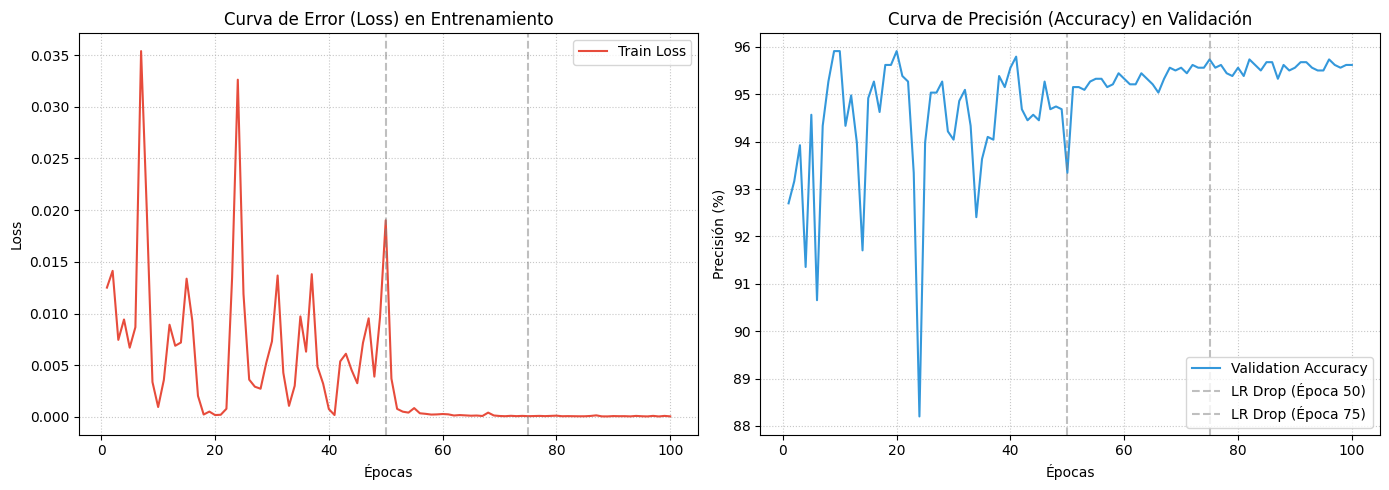

In [ ]:
# CELDA 4: Entrenamiento, Validación y Trazabilidad
import matplotlib.pyplot as plt

EPOCHS = 100
criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001)

# Programador para reducir el Learning Rate en las épocas 50 y 75 por un factor de 0.1
scheduler = optim.lr_scheduler.MultiStepLR(optimizador, milestones=[50, 75], gamma=0.1)

print("Iniciando entrenamiento...")
best_val_acc = 0.0

# Listas para guardar la trazabilidad (historial) de cada métrica
historial_train_loss = []
historial_val_acc = []

for epoch in range(EPOCHS):
    # --- ENTRENAMIENTO ---
    modelo.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device).squeeze().long()

        optimizador.zero_grad()
        outputs = modelo(inputs)
        loss = criterio(outputs, targets)
        loss.backward()
        optimizador.step()

        train_loss += loss.item()

    scheduler.step() # Actualizar la tasa de aprendizaje

    # Calcular y guardar el loss promedio de la época
    avg_train_loss = train_loss / len(train_loader)
    historial_train_loss.append(avg_train_loss)

    # --- VALIDACIÓN ---
    modelo.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
            outputs = modelo(inputs)
            _, predicciones = torch.max(outputs, 1)
            val_corrects += (predicciones == targets).sum().item()

    # Calcular y guardar la precisión de validación
    val_acc = 100 * val_corrects / len(val_dataset)
    historial_val_acc.append(val_acc)

    current_lr = optimizador.param_groups[0]['lr']

    # Guardar el mejor modelo temporalmente
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(modelo.state_dict(), 'mejor_modelo_bloodmnist.pth')

    # Imprimir el progreso ESTRICTAMENTE ÉPOCA POR ÉPOCA
    print(f"Época [{epoch+1:03d}/{EPOCHS}] | LR: {current_lr:.6f} | Error Train: {avg_train_loss:.4f} | Precisión Val: {val_acc:.2f}%")

print(f"\nEntrenamiento finalizado. Mejor precisión en validación: {best_val_acc:.2f}%")

# ==========================================
# GRÁFICOS DE TRAZABILIDAD
# ==========================================
plt.figure(figsize=(14, 5))

# Gráfico 1: Evolución del Error de Entrenamiento (Loss)
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), historial_train_loss, label='Train Loss', color='#e74c3c')
plt.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=75, color='gray', linestyle='--', alpha=0.5)
plt.title('Curva de Error (Loss) en Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# Gráfico 2: Evolución de la Precisión de Validación (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), historial_val_acc, label='Validation Accuracy', color='#3498db')
plt.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='LR Drop (Época 50)')
plt.axvline(x=75, color='gray', linestyle='--', alpha=0.5, label='LR Drop (Época 75)')
plt.title('Curva de Precisión (Accuracy) en Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión (%)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

Evaluando modelo en el conjunto de Test...

*** PRECISIÓN FINAL EN TEST: 94.94% ***

REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

    Basophil       0.93      0.92      0.92       244
  Eosinophil       1.00      0.98      0.99       624
Erythroblast       0.97      0.95      0.96       311
          IG       0.89      0.87      0.88       579
  Lymphocyte       0.95      0.95      0.95       243
    Monocyte       0.86      0.92      0.89       284
  Neutrophil       0.96      0.97      0.97       666
    Platelet       1.00      1.00      1.00       470

    accuracy                           0.95      3421
   macro avg       0.94      0.95      0.94      3421
weighted avg       0.95      0.95      0.95      3421



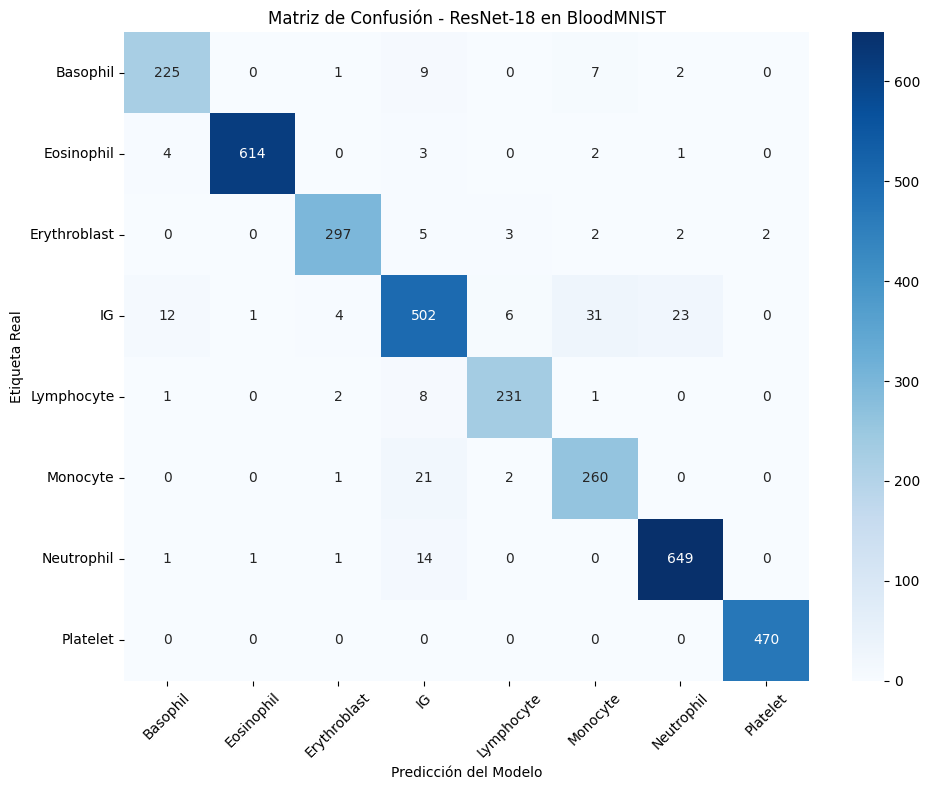

In [ ]:
# CELDA 5: Test y Evaluación de Resultados
# Cargar los pesos del mejor modelo obtenido durante la validación
modelo.load_state_dict(torch.load('mejor_modelo_bloodmnist.pth'))
modelo.eval()

todas_predicciones = []
todas_etiquetas = []

print("Evaluando modelo en el conjunto de Test...")
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.squeeze().long().numpy()

        outputs = modelo(inputs)
        _, preds = torch.max(outputs, 1)

        todas_predicciones.extend(preds.cpu().numpy())
        todas_etiquetas.extend(targets)

# Resultados Globales
acc = np.mean(np.array(todas_predicciones) == np.array(todas_etiquetas))
print(f"\n*** PRECISIÓN FINAL EN TEST: {acc * 100:.2f}% ***\n")

# Nombres de las clases para BloodMNIST
nombres_clases = ['Basophil', 'Eosinophil', 'Erythroblast', 'IG', 'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet']

# Reporte de Clasificación (incluye F1-Score)
print("REPORTE DE CLASIFICACIÓN:")
print(classification_report(todas_etiquetas, todas_predicciones, target_names=nombres_clases))

# Matriz de Confusión
matriz = confusion_matrix(todas_etiquetas, todas_predicciones)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión - ResNet-18 en BloodMNIST')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
### 🔬 Prueba Interactiva: Sube tu propia imagen

Oye, en la siguiente celda de código puedes subir **cualquier foto de una célula sanguínea** (en formato `.jpg`, `.png`, etc.) para poner a prueba las predicciones del modelo.

> **⚠️ Ojo con el margen de error:**
> Es muy probable que el modelo se equivoque o confunda las clases si subes una foto real de alta definición sacada de internet o de un laboratorio. Ten en cuenta que la calidad de los datos de entrenamiento de BloodMNIST es intencionalmente baja; todas sus imágenes están comprimidas a un tamaño de apenas **28x28 píxeles**[cite: 1].
>
> Debido a esta pérdida masiva de detalles, el resultado es solo una aproximación algorítmica. Este dataset está diseñado como un *benchmark* ligero para probar redes neuronales de forma rápida, y los propios creadores del proyecto advierten explícitamente que los resultados **no están destinados para uso clínico**[cite: 1].

¡Ejecuta la celda, dale al botón de subir archivo y mira qué predice la red!
---

Sube una imagen de una célula sanguínea para clasificarla:


Saving Neutrophils.jpg to Neutrophils (1).jpg

Procesando la imagen: "Neutrophils (1).jpg"...


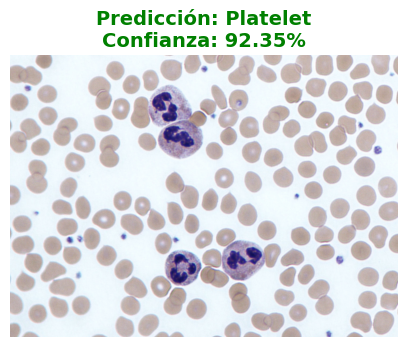

--- Top 3 Probabilidades ---
1. Platelet: 92.35%
2. Eosinophil: 4.01%
3. IG: 3.55%


In [ ]:
# CELDA 6: Prueba Interactiva del Modelo
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import io
import torch.nn.functional as F

# 1. Asegurarnos de usar el mejor modelo guardado y ponerlo en modo evaluación
modelo.load_state_dict(torch.load('mejor_modelo_bloodmnist.pth'))
modelo.eval()

# 2. Definir las transformaciones
# Añadimos Resize(28, 28) por si subes una imagen más grande que las del dataset original
transformacion_interactiva = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

nombres_clases = ['Basophil', 'Eosinophil', 'Erythroblast', 'IG', 'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet']

print("Sube una imagen de una célula sanguínea para clasificarla:")
uploaded = files.upload()

# 3. Procesar la imagen subida
for fn in uploaded.keys():
    print(f'\nProcesando la imagen: "{fn}"...')

    # Leer la imagen y asegurar que tenga 3 canales (RGB)
    imagen_bytes = uploaded[fn]
    imagen_pil = Image.open(io.BytesIO(imagen_bytes)).convert('RGB')

    # Aplicar transformaciones y añadir la dimensión del batch (1, 3, 28, 28)
    tensor_imagen = transformacion_interactiva(imagen_pil).unsqueeze(0).to(device)

    # 4. Hacer la predicción
    with torch.no_grad():
        salida = modelo(tensor_imagen)

        # Obtener las probabilidades con Softmax
        probabilidades = F.softmax(salida, dim=1)[0]

        # Obtener la clase con mayor probabilidad
        _, prediccion = torch.max(salida, 1)
        clase_predicha = nombres_clases[prediccion.item()]
        confianza = probabilidades[prediccion.item()] * 100

    # 5. Mostrar la imagen y el resultado
    plt.figure(figsize=(5, 5))
    plt.imshow(imagen_pil)
    plt.axis('off')

    # Cambiar el color del texto dependiendo de la confianza
    color_titulo = 'green' if confianza > 80 else 'orange'

    plt.title(f'Predicción: {clase_predicha}\nConfianza: {confianza:.2f}%',
              fontsize=14, color=color_titulo, fontweight='bold')
    plt.show()

    # Imprimir el top 3 de probabilidades para más detalle
    print("--- Top 3 Probabilidades ---")
    top3_prob, top3_clases = torch.topk(probabilidades, 3)
    for i in range(3):
        nombre = nombres_clases[top3_clases[i].item()]
        prob = top3_prob[i].item() * 100
        print(f"{i+1}. {nombre}: {prob:.2f}%")

---
### 🧪 Validación Aleatoria con Datos Oficiales (Archivo `.npz`)

A diferencia de la prueba anterior con imágenes externas, la siguiente celda evaluará el modelo utilizando **las imágenes originales de prueba**.

Para esto, el código extraerá aleatoriamente una muestra del conjunto `test_dataset`, el cual fue cargado directamente desde el archivo comprimido `bloodmnist.npz` proporcionado por la API de MedMNIST[cite: 1].

**¿Qué hace esta celda?**
1. **Selección aleatoria:** Escoge al azar una de las imágenes de prueba que la red neuronal **nunca vio durante su entrenamiento**.
2. **Visualización de la compresión:** Muestra la imagen en su resolución real de 28x28 píxeles[cite: 1] para observar cómo el algoritmo percibe la información.
3. **Inferencia en tiempo real:** Pone a prueba el modelo y compara la predicción matemática con la etiqueta real, marcando el resultado en verde si la predicción es correcta y en rojo si el modelo se equivoca.

*Tip: Puedes ejecutar esta celda repetidas veces ("Play") para generar y evaluar diferentes muestras de forma dinámica.*
---

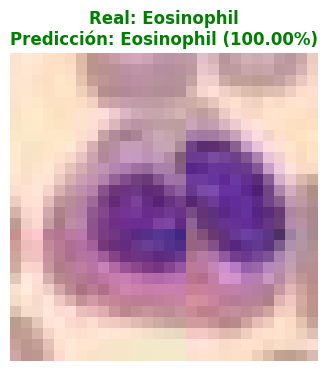

--- Top 3 Probabilidades ---
1. Eosinophil: 100.00%
2. IG: 0.00%
3. Basophil: 0.00%


In [ ]:
# CELDA 7: Prueba interactiva con una imagen del archivo .npz
import random
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np

# 1. Elegir un índice al azar de las 3,421 imágenes de prueba
indice = random.randint(0, len(test_dataset) - 1)

# 2. Extraer la imagen y su etiqueta real directamente del dataset
imagen_tensor, etiqueta_real = test_dataset[indice]
etiqueta_real = etiqueta_real.item() # Convertir el tensor a número

# Nombres de las clases
nombres_clases = ['Basophil', 'Eosinophil', 'Erythroblast', 'IG', 'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet']
clase_real = nombres_clases[etiqueta_real]

# 3. Preparar la imagen para mostrarla (Deshacer la normalización de [-1, 1] a [0, 1])
# PyTorch usa (Canales, Alto, Ancho), Matplotlib usa (Alto, Ancho, Canales)
imagen_mostrar = (imagen_tensor / 2 + 0.5).permute(1, 2, 0).numpy()

# 4. Poner a prueba el modelo
modelo.eval()
with torch.no_grad():
    # Añadir la dimensión de batch (1, 3, 28, 28) y enviar a la GPU
    entrada = imagen_tensor.unsqueeze(0).to(device)
    salida = modelo(entrada)

    # Obtener probabilidades
    probabilidades = F.softmax(salida, dim=1)[0]
    _, prediccion = torch.max(salida, 1)

    clase_predicha = nombres_clases[prediccion.item()]
    confianza = probabilidades[prediccion.item()] * 100

# 5. Mostrar los resultados
plt.figure(figsize=(4, 4))
plt.imshow(imagen_mostrar)
plt.axis('off')

# Título en verde si acertó, rojo si se equivocó
color_titulo = 'green' if clase_predicha == clase_real else 'red'

plt.title(f'Real: {clase_real}\nPredicción: {clase_predicha} ({confianza:.2f}%)',
          fontsize=12, color=color_titulo, fontweight='bold')
plt.show()

# Imprimir el Top 3 de probabilidades
print("--- Top 3 Probabilidades ---")
top3_prob, top3_clases = torch.topk(probabilidades, 3)
for i in range(3):
    nombre = nombres_clases[top3_clases[i].item()]
    prob = top3_prob[i].item() * 100
    print(f"{i+1}. {nombre}: {prob:.2f}%")